### ScratchML: From-Scratch Optimization Engine
Step 1: Environment & Matrix Math Setup

Before touching the data, set up your mathematical workspace in a Jupyter Notebook.
* Imports: Only allow yourself to use numpy, pandas, and matplotlib (for plotting curves). Do not import scikit-learn models.
* The Math Checklist: Keep the formulas you are translating into code right in front of you:

Normal Equation: $\theta = (X^T X)^{-1} X^T y$

Batch Gradient Descent Step: $\theta = \theta - \alpha \frac{2}{m} X^T (X\theta - y)$

In [2]:
pip install pandas numpy scikit-learn seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Optional: This ensures your plots display cleanly inside the notebook
%matplotlib inline

Step 2: Data Selection & Engineering (The Pandas Phase)

The full Kaggle dataset has 79 features, many of which are text/categorical or full of missing values. For a scratch NumPy implementation, you want to cherry-pick a few highly correlated, continuous numerical features to keep your matrices clean.
* Load the Data: Read train.csv using Pandas.
* Feature Selection: Select 3 to 5 continuous numerical variables that heavily influence house prices.
1. Good options:GrLivArea (Above ground living area square feet)
2. GarageArea (Size of garage in square feet)
3. TotalBsmtSF (Total square feet of basement area)
4.Target Variable: Set your $y$ vector as SalePrice.

Handle Missing Values: Drop any rows with missing values in your selected features, or fill them with the column mean using Pandas: .fillna(df.mean()).

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Load the dataset
df = pd.read_csv('train.csv')

# Display the first 5 rows to see what the data looks like
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
numerical_df = df.select_dtypes(include=[np.number])

correlations = numerical_df.corr()['SalePrice'].sort_values(ascending=False)
print(correlations.head(10))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


In [7]:
# Choose your features based on high correlation
# GrLivArea: Above ground living area sq feet
# TotalBsmtSF: Total square feet of basement area
# GarageArea: Size of garage in square feet
feature_cols = ['GrLivArea', 'TotalBsmtSF', 'GarageArea']

# (x) features and (y) target varaiables
X_raw = df[feature_cols].copy()
y = df['SalePrice'].values.reshape(-1, 1)

# Handle any missing values by filling them with the column mean
X_raw = X_raw.fillna(X_raw.mean())

# Convert the features DataFrame to a clean NumPy array
X_mat = X_raw.values

print(f"Shape of feature matrix X_mat: {X_mat.shape}")
print("Shape of target vector y:", y.shape)

Shape of feature matrix X_mat: (1460, 3)
Shape of target vector y: (1460, 1)


Step 3 (Crucial Data Preprocessing), we need to transform your raw data so that our custom mathematical formulas work smoothly.

1. Feature Scaling (Standardization) from ScratchWe will normalize our features so they all have a mean ($\mu$) of 0 and a standard deviation ($\sigma$) of 1. Since we aren't using scikit-learn, we calculate this directly using NumPy:$$X_{scaled} = \frac{X - \mu}{\sigma}$$

In [8]:
means = np.mean(X_mat, axis = 0) # mean
stds = np.std(X_mat, axis = 0) # standard deviation 

X_scaled = (X_mat - means) / stds

print("Scaled feature sample (first 3 rows): \n", X_scaled[:3])
print("\nNew Means (should be ~0):", np.round(np.mean(X_scaled, axis = 0), 2))
print("New Standard Deviations (Should be 1):", np.std(X_scaled, axis=0))

Scaled feature sample (first 3 rows): 
 [[ 0.37033344 -0.45930254  0.35100032]
 [-0.48251191  0.46646492 -0.06073101]
 [ 0.51501256 -0.31336875  0.63172623]]

New Means (should be ~0): [-0.  0. -0.]
New Standard Deviations (Should be 1): [1. 1. 1.]


2. Add the Bias / Intercept Term ($X_0$)

A standard linear equation looks like $y = m_1x_1 + m_2x_2 + m_3x_3 + c$, where $c$ is the constant intercept.

To solve this cleanly using matrix math, we turn that constant into a weight ($\theta_0$) by adding a column containing entirely $1$s to the very front of our feature matrix. This changes our equation into a neat dot product: $\hat{y} = X \cdot \theta$.

We calculate $X_b$ to include a bias term (also called the intercept) directly inside the linear regression mathematical formula.
Here is exactly why this is done:
## 1. It Accounts for the Base Value
A standard linear regression equation looks like this:
$$y = \theta_0 + \theta_1x_1 + \theta_2x_2 + \dots$$ 

* $\theta_0$ is the bias/intercept. It represents the expected value of $y$ when all your features ($x$) are zero. For example, even if a house has 0 square feet, the land itself still has a base price.

## 2. It Simplifies the Mathematics
By adding a column of entirely 1s to the front of your data matrix, you turn the standalone $\theta_0$ into a matrix multiplication step ($\theta_0 \times 1$). This allows the entire equation to be written cleanly as:
$$\hat{y} = X_b \cdot \theta$$ 
## 3. It is Required for the Normal Equation
The mathematical formula shown at the bottom of your screen $\theta = (X^T X)^{-1} X^T y$ solves for all weights simultaneously. If you do not add that column of ones to your matrix, the algorithm will force the regression line to pass exactly through the origin $(0,0)$, which heavily breaks the accuracy of your model.


In [9]:
# Get the number of rows (instances) in our dataset
m = len(X_scaled)

# Create a column vector of ones with shape (1460, 1)
bias_column = np.ones((m, 1))

# Concatenate the ones column to the left of our scaled features
X_b = np.c_[bias_column, X_scaled]  # feature matrix 

print("Original scaled shape:", X_scaled.shape)
print("New feature matrix shape (with bias column):", X_b.shape)
print("\nFirst 3 rows of X_b:\n", X_b[:3])

Original scaled shape: (1460, 3)
New feature matrix shape (with bias column): (1460, 4)

First 3 rows of X_b:
 [[ 1.          0.37033344 -0.45930254  0.35100032]
 [ 1.         -0.48251191  0.46646492 -0.06073101]
 [ 1.          0.51501256 -0.31336875  0.63172623]]


Step 4: Implement Algorithm 

1 – The Normal Equation.

the Normal Equation is an analytical method that solves for the optimal weights ($\theta$) in a single mathematical step. 

It doesn't use loops, it doesn't require a learning rate, and it gives you the mathematically absolute best possible parameters for your linear regression model.

The mathematical formula is:$$\theta = (X^T X)^{-1} X^T y$$

We will translate that exact formula into a single line of NumPy code using the following operators:
* .T for matrix transposition ($X^T$)
* np.linalg.inv() to calculate the matrix inverse ($^{-1}$)
* @ for matrix dot-product multiplication

In [10]:
theta_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print("--- Normal Equation Results ---")
print(f"Intercept (theta_0): {theta_normal[0][0]:.2f}")
print(f"GrLivArea Weight (theta_1): {theta_normal[1][0]:.2f}")
print(f"TotalBsmtSF Weight (theta_2): {theta_normal[2][0]:.2f}")
print(f"GarageArea Weight (theta_3): {theta_normal[3][0]:.2f}")

--- Normal Equation Results ---
Intercept (theta_0): 180921.20
GrLivArea Weight (theta_1): 36114.91
TotalBsmtSF Weight (theta_2): 21553.10
GarageArea Weight (theta_3): 22083.04


2 - Make a Mock Prediction (Sanity Check)

To make sure our model can actually make predictions using these weights, let's write out the hypothesis function: $\hat{y} = X_b \cdot \theta$.

In [11]:
# Generate prediction for entire dataset

y_pred_normal = X_b @ theta_normal

for i in range(3):
    print(f"House {i+1}: Predicted Price = ${y_pred_normal[i][0]:,.2f} | Actual Price = ${y[i][0]:,.2f}")
    

House 1: Predicted Price = $192,147.51 | Actual Price = $208,500.00
House 2: Predicted Price = $172,207.96 | Actual Price = $181,500.00
House 3: Predicted Price = $206,717.19 | Actual Price = $223,500.00


Step 5: Implement Algorithm 2 – Batch Gradient Descent.

Unlike the Normal Equation which calculates the answer instantly, Gradient Descent is an optimization concept where the model starts with completely random guesses and iteratively walks down the error landscape to find the minimum of the cost function (Mean Squared Error).

The math we are translating into a loop for this step is:
$$\theta = \theta - \alpha \frac{2}{m} X_b^T (X_b\theta - y)$$Where $\alpha$ (alpha) is your learning rate, and $m$ is the total number of rows.

In [21]:
learning_rate = 0.05
n_iterations = 1000
m = len(X_b)

# Number of instances (1460)

# Initialize weights to zeros (Start at a random position on the hill)
# Shape needs to be (4, 1) to match our 4 features (1 bias + 3 physical features)
theta_gd = np.zeros((X_b.shape[1], 1))

# Create a list to store the cost (MSE) at each iteration for plotting later
cost_history = []

# The Optimization loop
for i in range(n_iterations):
    # 1. cal predictions (Y_hat = X . theta)
    y_pred = X_b @ theta_gd

    # 2. Calculate the difference between predictions and actual prices (Error)
    error = y_pred - y

    # 3. Compute Mean Squared Error Cost for tracking
    cost = (1 / m) * np.sum(error ** 2)
    cost_history.append(cost)

    ''' We store the cost inside that cost_history list for two vital reasons: 
         one is for optimization diagnosis (making sure your code isn't broken)
         and the other is for mathematical convergence verification.'''

    
    # 4. Calculate gradients (The slope of the cost curve at our current position)
    gradients = (2 / m) * X_b.T @ error

    # 5. Update weights by moving down the slope
    #it is the moment where your model actually "learns" by adjusting its parameters to minimize error.
    theta_gd = theta_gd - learning_rate * gradients

print("--- Batch Gradient Descent Complete ---")
print(f"Final Intercept (theta_0): {theta_gd[0][0]:.2f}")
print(f"GrLivArea Weight (theta_1): {theta_gd[1][0]:.2f}")
print(f"TotalBsmtSF Weight (theta_2): {theta_gd[2][0]:.2f}")
print(f"GarageArea Weight (theta_3): {theta_gd[3][0]:.2f}")

--- Batch Gradient Descent Complete ---
Final Intercept (theta_0): 180921.20
GrLivArea Weight (theta_1): 36114.91
TotalBsmtSF Weight (theta_2): 21553.10
GarageArea Weight (theta_3): 22083.04




### Step 1: Calculate Predictions ($\hat{\mathbf{y}}$)

* **Python Code:** `y_pred = X_b @ theta_gd`
* **Mathematical Formula:** 
$$\hat{\mathbf{y}} = \mathbf{X}_b \boldsymbol{\theta}$$


* **What the math means:** $\mathbf{X}_b$ is an $m \times (n+1)$ matrix (shape $1460 \times 4$) and $\boldsymbol{\theta}$ is a column vector of weights (shape $4 \times 1$). The matrix multiplication computes the dot product for every single house simultaneously, resulting in a vector of predicted prices $\hat{\mathbf{y}}$ of shape $1460 \times 1$.

---

### Step 2: Calculate Error

* **Python Code:** `error = y_pred - y`
* **Mathematical Formula:** 
$$\mathbf{e} = \hat{\mathbf{y}} - \mathbf{y}$$


* **What the math means:** This is simple vector subtraction. It subtracts the actual target price vector $\mathbf{y}$ from your prediction vector $\hat{\mathbf{y}}$. The resulting vector $\mathbf{e}$ contains the raw error amount (residual) for each individual house.

---

### Step 3: Compute Mean Squared Error (MSE) Cost

* **Python Code:** `cost = (1 / m) * np.sum(error  2)`
* **Mathematical Formula:** 
$$J(\boldsymbol{\theta}) = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)^2$$



Alternatively, written in pure vector notation:


$$J(\boldsymbol{\theta}) = \frac{1}{m} \mathbf{e}^T \mathbf{e}$$

* **What the math means:** This is the objective function (or cost function). It takes every single error value, squares it (to remove negative signs and punish large mistakes more severely), sums them all up, and divides by $m$ to find the average. This single scalar value tells you how "wrong" your current weights are.

---

### Step 4: Calculate Gradients ($\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta})$)

* **Python Code:** `gradients = (2 / m) * X_b.T @ error`
* **Mathematical Formula:** 
$$\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta}) = \frac{2}{m} \mathbf{X}_b^T (\mathbf{X}_b \boldsymbol{\theta} - \mathbf{y})$$


* **What the math means:** This formula calculates the partial derivative of the cost function with respect to every single weight in $\boldsymbol{\theta}$. By transposing the feature matrix ($\mathbf{X}_b^T$) and multiplying it by the error vector, you are mathematically calculating the slope of the error hill for each feature. The resulting vector contains 4 gradient values, showing you which direction is "up" the hill for each weight.

---

### Step 5: Update Weights (The Descent Step)

* **Python Code:** `theta_gd = theta_gd - learning_rate * gradients`
* **Mathematical Formula:** 
$$\boldsymbol{\theta}^{(\text{next step})} = \boldsymbol{\theta} - \alpha \nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta})$$


* **What the math means:** Since the gradient points *up* the hill toward higher error, we subtract a fraction of it to move *down* the hill toward the valley minimum. $\alpha$ (learning rate) controls how massive of a step we take.

---

### The Complete Combined Math Equation

If you combine steps 4 and 5 into a single mathematical statement for the whole algorithm iteration, it looks exactly like the equation in Chapter 4 of your book:

$$\boldsymbol{\theta}^{(\text{next step})} = \boldsymbol{\theta} - \alpha \frac{2}{m} \mathbf{X}_b^T (\mathbf{X}_b \boldsymbol{\theta} - \mathbf{y})$$


2. Conceptual Check: Verify Your Curve

To make sure your Gradient Descent didn't overshoot or fail to converge, you must visually inspect the cost reduction. Run this code to plot your cost_history:

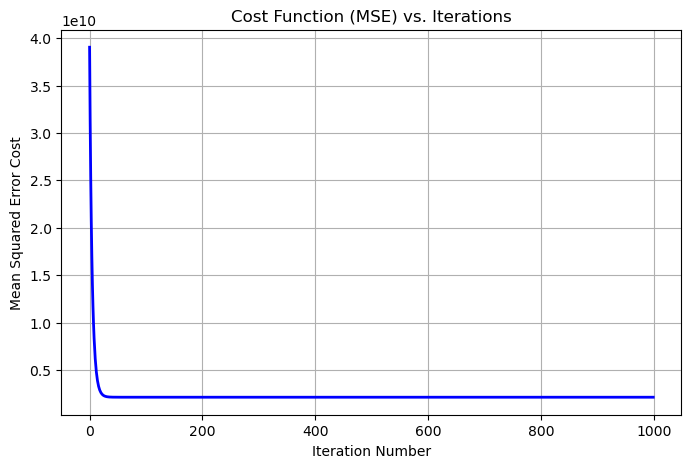

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(range(n_iterations), cost_history, color='blue', linewidth=2)
plt.title("Cost Function (MSE) vs. Iterations")
plt.xlabel("Iteration Number")
plt.ylabel("Mean Squared Error Cost")
plt.grid(True)
plt.show()

Step 6: Implement Algorithm 3 – Mini-Batch Gradient Descent with Early Stopping.


Mini-Batch Gradient Descent: Instead of calculating gradients using all 1,460 rows at once (Batch GD), we chop the data into smaller random chunks (e.g., 32 rows). This makes processing incredibly fast and allows the model to handle massive datasets that wouldn't fit in your computer's RAM.

Early Stopping: We split the data into Training and Validation sets. We monitor the validation error, and the moment it stops improving, we freeze training. This prevents overfitting (where the model memorizes the training data but fails on real-world test data).

1. Split Data into Train and Validation Sets
Before starting the loop, we must split our matrix X_b and target vector y into an 80% training set and a 20% validation set. Run this code cell:

In [20]:
# Set seed for reproducibility
np.random.seed(42)

#shuffle indices randomly
shuffled_indices = np.random.permutation(len(X_b))
train_size = int(len(X_b) * 0.8)

#split indices 
train_indices = shuffled_indices[:train_size]
val_indices = shuffled_indices[train_size:]

# create a final train and validation matrices
X_train, y_train = X_b[train_indices], y[train_indices]
X_val, y_val = X_b[val_indices], y[val_indices]

print(f'Training set shape: {X_train.shape}')
print(f'Validation set shape: {X_val.shape}')

Training set shape: (1168, 4)
Validation set shape: (292, 4)


2. The Mini-Batch + Early Stopping Loop
Run this next code block. It introduces nested loops: the outer loop runs through epochs (full passes over the dataset), and the inner loop iterates through mini-batches of size 32.

It also includes "patience" logic: if validation loss doesn't improve for 10 epochs straight, it breaks the loop completely.

In [24]:
#Hyperparameters
learning_rate = 0.05
n_epochs = 500
batch_size = 32
patience = 10

#initialize parameters
theta_mini = np.zeros((X_train.shape[1], 1))

#tracking variables
best_val_loss = float('inf')
best_theta = None
patience_counter = 0

train_loss_history = []
val_loss_history = []

m_train = len(X_train)

for epoch in range(n_epochs):
    # Shuffle training data at the start of every epoch
    ''' It completely shuffles the order of your houses.
    Why we do it: If your dataset happens to be sorted 
    (e.g., cheap houses first, expensive houses last),
    the mini-batches at the start of the loop would train the model to only predict low values,
    and the mini-batches at the end would force it to wildly overcorrect.
    Shuffling breaks up any artificial ordering, ensuring each batch is a fair, 
    representative cross-section of the whole dataset. '''
    
    shuffled_epoch_indices = np.random.permutation(m_train)
    X_train_shuffled = X_train[shuffled_epoch_indices]
    y_train_shuffled = y_train[shuffled_epoch_indices]

    # Inner Loop: Mini-Batches
    ''' Since batch_size = 32, this loop jumps forward by 32 rows on every iteration
    (e.g., indices 0–32, then 32–64, then 64–96, etc.). '''
    for i in range(0, m_train, batch_size):
        # Extract the mini-batch slice
        ''' Instead of performing matrix math on all 1,168 training rows,
        it slices out a tiny matrix of just 32 houses (X_batch)
        and their corresponding actual prices (y_batch).'''
        X_batch = X_train_shuffled[i : i + batch_size]
        y_batch = y_train_shuffled[i : i + batch_size]
        
        # Calculate gradients based only on mini-batch
        ''' This is the exact same gradient descent math you used in Step 5, 
        but look at the scope: the model calculates the errors and updates its parameters based only on 
        these 32 houses. Because it calculates gradients on a small sample, it moves much faster computationally. 
        However, because 32 houses don't represent the entire dataset perfectly, the trajectory toward 
        the bottom of the error hill bounces around slightly (introducing a helpful amount of mathematical "noise").'''
        m_batch = len(X_batch)
        y_pred_batch = X_batch @ theta_mini
        error_batch = y_pred_batch - y_batch
        gradients = (2 / m_batch) * X_batch.T @ error_batch

        #update weigths
        theta_mini = theta_mini - learning_rate * gradients

    # --- End of Epoch Evaluations ---
    # 1. Calculate overall Training Loss for this epoch
    train_loss = (1 / m_train) * np.sum((X_train @ theta_mini - y_train) ** 2)
    train_loss_history.append(train_loss)

    ''' The model evaluates its performance across the entire training set and the entire validation set
    using its updated weights, appending those tracking metrics to your history lists. '''
    
    # 2. Calculate overall Validation Loss for this epoch
    val_loss = (1 / len(X_val)) * np.sum((X_val @ theta_mini - y_val) ** 2)
    val_loss_history.append(val_loss)

    # 3. Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_theta = theta_mini.copy() # saves a copy of best weight
        paitence_counter = 0 #Reset counter since we improved
        
        '''If validation loss improves: The code says, "Great! This is the lowest error we've ever seen on unseen data." 
        It saves a snapshot of these weights into best_theta and sets the patience_counter back to 0.'''
    
    else:
        paitence_counter += 1

    # Trigger Early Stopping break
    if patience_counter >= patience:
        print(f"Early stopping triggered at Epoch {epoch}! Validation loss stopped improving.")
        break
    ''' If the validation loss fails to find a new record low for 10 consecutive epochs
    (patience = 10), the outer loop triggers a break command, halting training immediately.'''
# Restore the best parameters found before overfitting started
theta_mini = best_theta     
'''Because the loop only stops after 10 epochs of zero improvement, the final parameters inside theta_mini
are slightly degraded or overfitted. This final line overwrites those flawed parameters and restores the exact weight snapshot from your best performing validation epoch.'''

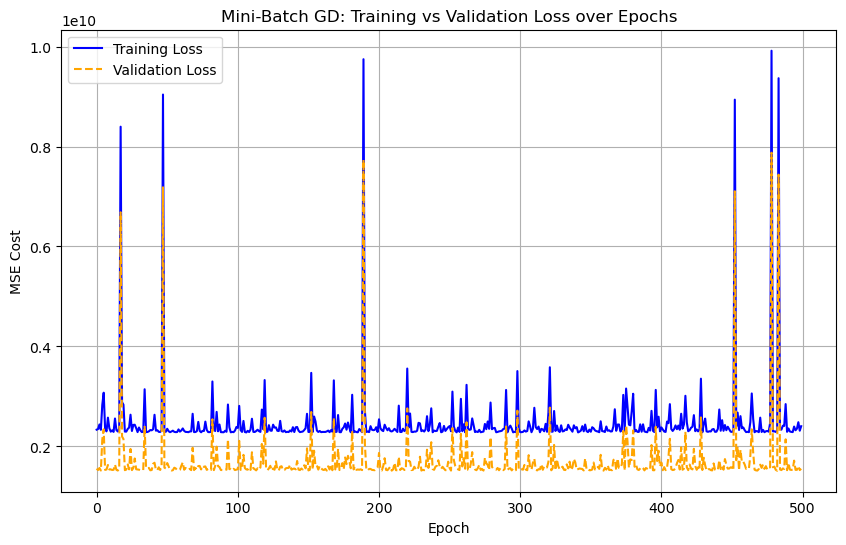

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label="Training Loss", color="blue")
plt.plot(val_loss_history, label="Validation Loss", color="orange", linestyle="--")
plt.title("Mini-Batch GD: Training vs Validation Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Cost")
plt.legend()
plt.grid(True)
plt.show()

Step 7: The Master Evaluation & Verification Grid.

This is the final milestone of your project! The core objective here is to evaluate the outputs of all three models you built from scratch—The Normal Equation, Batch Gradient Descent, and Mini-Batch Gradient Descent with Early Stopping—and display them side-by-side.

This step serves as your code validation. Because all three algorithms optimize for the exact same target function (Mean Squared Error), their learned weights should match up closely.

In [27]:
# Create a dictionary containing weights from all three methods
evaluation_data = {
    'Feature': ['Intercept (Bias)', 'GrLivArea (Sq Ft)', 'TotalBsmtSF (Basement)', 'GarageArea (Garage)'],
    'Normal Equation (Step 4)': [theta_normal[0][0], theta_normal[1][0], theta_normal[2][0], theta_normal[3][0]],
    'Batch GD (Step 5)': [theta_gd[0][0], theta_gd[1][0], theta_gd[2][0], theta_gd[3][0]],
    'Mini-Batch GD (Step 6)': [theta_mini[0][0], theta_mini[1][0], theta_mini[2][0], theta_mini[3][0]]
}

# Convert to a DataFrame for clean, tabular display
df_eval = pd.DataFrame(evaluation_data)

# Round the values to 2 decimal places for readable presentation
df_eval = df_eval.round(2)

# Display the master verification table
print("=== FROM-SCRATCH MODEL VERIFICATION MATRIX ===")
df_eval

=== FROM-SCRATCH MODEL VERIFICATION MATRIX ===


,Feature,Normal Equation (Step 4),Batch GD (Step 5),Mini-Batch GD (Step 6)
0,Intercept (Bias),180921.20,180921.20,180413.28
1,GrLivArea (Sq Ft),36114.91,36114.91,38447.31
2,TotalBsmtSF (Basement),21553.10,21553.10,25815.66
3,GarageArea (Garage),22083.04,22083.04,21344.02


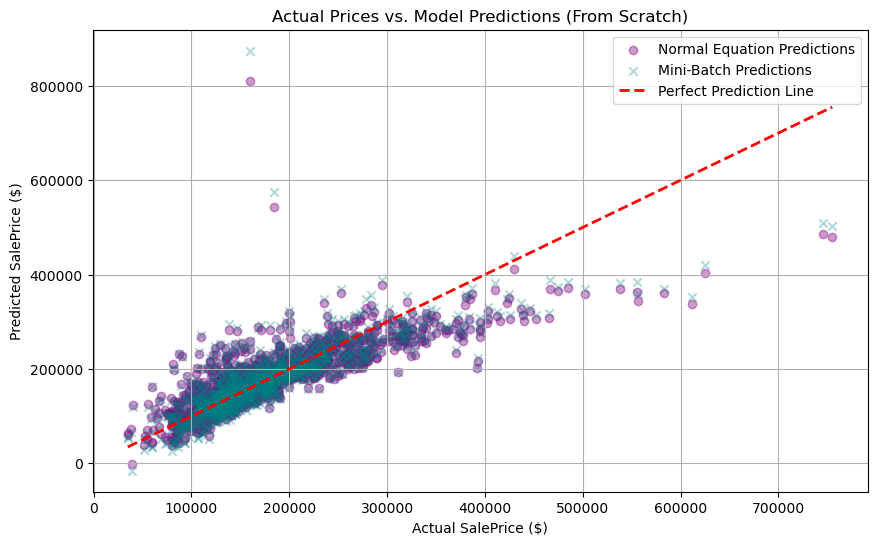

In [28]:
# Generate predictions across the whole dataset for visualization
predictions_normal = X_b @ theta_normal
predictions_mini = X_b @ theta_mini

plt.figure(figsize=(10, 6))
plt.scatter(y, predictions_normal, color='purple', alpha=0.4, label='Normal Equation Predictions')
plt.scatter(y, predictions_mini, color='teal', alpha=0.3, marker='x', label='Mini-Batch Predictions')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')
plt.title("Actual Prices vs. Model Predictions (From Scratch)")
plt.xlabel("Actual SalePrice ($)")
plt.ylabel("Predicted SalePrice ($)")
plt.legend()
plt.grid(True)
plt.show()